In [1]:
import pandas as pd

In [3]:
customer_churn_df = pd.read_csv(r'C:\Users\sumit\DATA_SCIENCE\THE DEVELOPER ARENA INTERNSHIP\Week 5\customer_churn.csv')
print('Customer Churn DataFrame Info:')
customer_churn_df.info()
print('\nCustomer Churn DataFrame Head:')
display(customer_churn_df.head())
sales_df = pd.read_csv(r'C:\Users\sumit\DATA_SCIENCE\THE DEVELOPER ARENA INTERNSHIP\Week 5\sales_data.csv')
print('Sales DataFrame Info:')
sales_df.info()
print('\nSales DataFrame Head:')
display(sales_df.head())

Customer Churn DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB

Customer Churn DataFrame Head:


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


Sales DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB

Sales DataFrame Head:


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [4]:
# Renaming 'Customer_ID' in sales_df to 'CustomerID' for a proper merge
sales_df = sales_df.rename(columns={'Customer_ID': 'CustomerID'})

# Standardizing CustomerID format in customer_churn_df to match sales_df
customer_churn_df['CustomerID'] = customer_churn_df['CustomerID'].apply(lambda x: x.replace('C', 'CUST'))

# Merging sales_df with customer_churn_df on CustomerID
merged_df = pd.merge(sales_df, customer_churn_df, on='CustomerID', how='left')

# Converting 'Date' column to datetime objects
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

# Extracting month and year from 'Date'
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Year'] = merged_df['Date'].dt.year

print('Merged DataFrame Info:')
merged_df.info()
print('\nMerged DataFrame Head:')
display(merged_df.head())

Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              100 non-null    datetime64[ns]
 1   Product           100 non-null    object        
 2   Quantity          100 non-null    int64         
 3   Price             100 non-null    int64         
 4   CustomerID        100 non-null    object        
 5   Region            100 non-null    object        
 6   Total_Sales       100 non-null    int64         
 7   Tenure            0 non-null      float64       
 8   MonthlyCharges    0 non-null      float64       
 9   TotalCharges      0 non-null      float64       
 10  Contract          0 non-null      object        
 11  PaymentMethod     0 non-null      object        
 12  PaperlessBilling  0 non-null      object        
 13  SeniorCitizen     0 non-null      float64       
 14  Chur

,Date,Product,Quantity,Price,CustomerID,Region,Total_Sales,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Month,Year
0,2024-01-01,Phone,7,37300,CUST001,East,261100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2024
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2024
2,2024-01-03,Phone,2,21746,CUST003,West,43492,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2024
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2024
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2024


In [5]:
# Total Sales by Year and Month
sales_by_month_year = merged_df.groupby(['Year', 'Month'])['Total_Sales'].sum().reset_index()
print('Total Sales by Year and Month:')
display(sales_by_month_year)

Total Sales by Year and Month:


,Year,Month,Total_Sales
0,2024,1,4120524
1,2024,2,2656050
2,2024,3,4485006
3,2024,4,1103468


In [6]:
# Total Sales by Product
sales_by_product = merged_df.groupby('Product')['Total_Sales'].sum().reset_index()
print('\nTotal Sales by Product:')
display(sales_by_product.sort_values(by='Total_Sales', ascending=False))


Total Sales by Product:


,Product,Total_Sales
1,Laptop,3889210
4,Tablet,2884340
3,Phone,2859394
0,Headphones,1384033
2,Monitor,1348071


In [7]:
# Top 10 Customers by Total Sales
top_customers = merged_df.groupby('CustomerID')['Total_Sales'].sum().reset_index()
top_customers = top_customers.sort_values(by='Total_Sales', ascending=False).head(10)
print('\nTop 10 Customers by Total Sales:')
display(top_customers)


Top 10 Customers by Total Sales:


,CustomerID,Total_Sales
15,CUST016,373932
6,CUST007,363870
82,CUST083,350888
72,CUST073,349510
19,CUST020,333992
83,CUST084,324144
69,CUST070,318762
4,CUST005,318680
64,CUST065,312564
27,CUST028,304465


In [8]:
# Pivot table: Total Sales by Product and Region
sales_region_product_pivot = merged_df.pivot_table(
    values='Total_Sales',
    index='Product',
    columns='Region',
    aggfunc='sum'
).fillna(0)
print('Total Sales by Product and Region (Pivot Table):')
display(sales_region_product_pivot)

Total Sales by Product and Region (Pivot Table):


Region,East,North,South,West
Product,,,,
Headphones,288361,107091,512168,476413
Laptop,221946,1798206,1373120,495938
Monitor,642870,397100,39924,268177
Phone,506828,489284,1471428,391854
Tablet,859634,1191954,341212,491540


In [9]:
# Pivot table: Average Monthly Charges and Churn Rate by Contract Type
churn_contract_pivot = customer_churn_df.pivot_table(
    values=['MonthlyCharges', 'Churn'],
    index='Contract',
    aggfunc={'MonthlyCharges': 'mean', 'Churn': 'mean'}
).rename(columns={'Churn': 'Churn Rate'})
print('\nAverage Monthly Charges and Churn Rate by Contract Type (Pivot Table):')
display(churn_contract_pivot)


Average Monthly Charges and Churn Rate by Contract Type (Pivot Table):


,Churn Rate,MonthlyCharges
Contract,,
Month-to-month,0.205882,112.829412
One year,0.043011,114.005376
Two year,0.069444,114.111111


In [30]:
# Calculate Total Revenue
total_revenue = merged_df['Total_Sales'].sum()

# Calculate Total Customers
total_customers = merged_df['CustomerID'].nunique()

# Calculate Average Order Value (assuming each row in merged_df is an order)
average_order_value = total_revenue / len(merged_df)

# Get Top Customer
# top_customers is already sorted, so the first row contains the top customer
if not top_customers.empty:
    top_customer_id = top_customers.iloc[0]['CustomerID']
    top_customer_sales = top_customers.iloc[0]['Total_Sales']
else:
    top_customer_id = 'N/A'
    top_customer_sales = 0

# Print the summary report
print("CUSTOMER SALES ANALYSIS REPORT")
print(f"Total Revenue: ${total_revenue:,.0f}")
print(f"Total Customers: {total_customers:,.0f}")
print(f"Average Order Value: ${average_order_value:,.0f}")
print(f"Top Customer: {top_customer_id} - ${top_customer_sales:,.0f}")

CUSTOMER SALES ANALYSIS REPORT
Total Revenue: $12,365,048
Total Customers: 100
Average Order Value: $123,650
Top Customer: CUST016 - $373,932


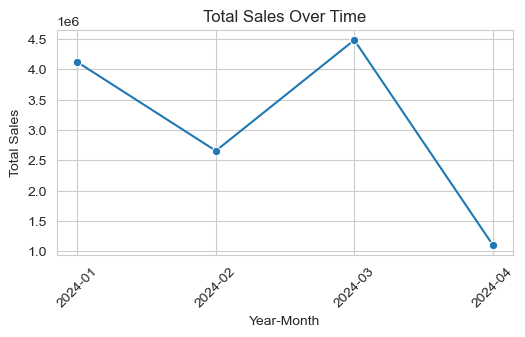

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(10, 9))

# Visualization 1: Total Sales Over Time (Line Plot)
plt.subplot(3, 2, 1) # 3 rows, 2 columns, 1st plot
sales_by_month_year['Date_YM'] = sales_by_month_year['Year'].astype(str) + '-' + sales_by_month_year['Month'].astype(str).str.zfill(2)
sns.lineplot(data=sales_by_month_year, x='Date_YM', y='Total_Sales', marker='o')
plt.title('Total Sales Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

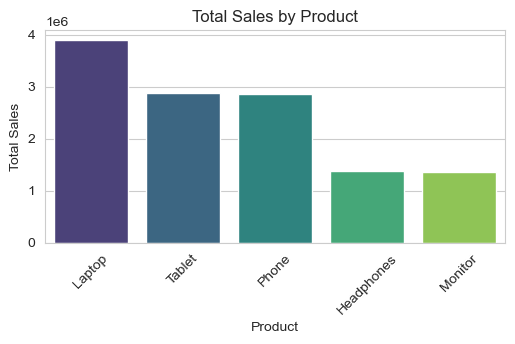

In [19]:
plt.figure(figsize=(10, 9))
# Visualization 2: Total Sales by Product (Bar Plot)
plt.subplot(3, 2, 2) # 3 rows, 2 columns, 2nd plot
sns.barplot(data=sales_by_product.sort_values(by='Total_Sales', ascending=False), x='Product', y='Total_Sales', hue='Product', legend=False, palette='viridis')
plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

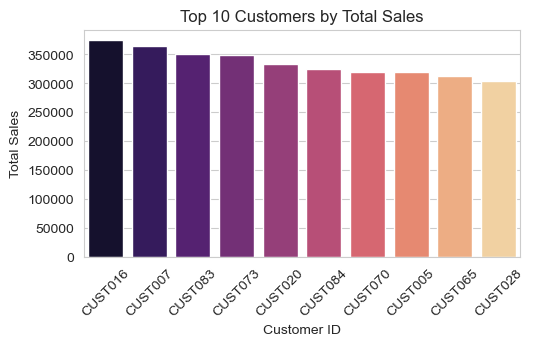

In [20]:
plt.figure(figsize=(10, 9))
# Visualization 3: Top 10 Customers by Total Sales (Bar Plot)
plt.subplot(3, 2, 3) # 3 rows, 2 columns, 3rd plot
sns.barplot(data=top_customers, x='CustomerID', y='Total_Sales', hue='CustomerID', legend=False, palette='magma')
plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Customer ID')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

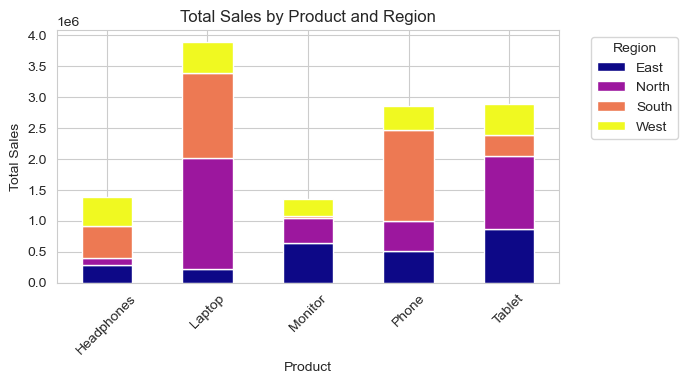

In [29]:
plt.figure(figsize=(12, 10))
# Visualization 4: Total Sales by Product and Region (Stacked Bar Chart or Heatmap)
plt.subplot(3, 2, 4) # 3 rows, 2 columns, 4th plot
sales_region_product_pivot.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='plasma')
plt.title('Total Sales by Product and Region')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

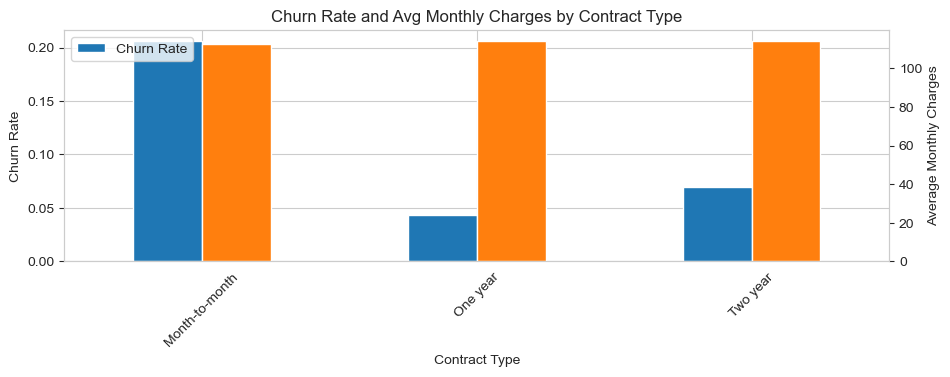

In [27]:
plt.figure(figsize=(18, 9))
# Visualization 5: Average Monthly Charges and Churn Rate by Contract Type (Bar Plot)
plt.subplot(3, 2, 5) # 3 rows, 2 columns, 5th plot
ax = churn_contract_pivot[['Churn Rate', 'MonthlyCharges']].plot(kind='bar', secondary_y='MonthlyCharges', ax=plt.gca(), rot=45)
plt.title('Churn Rate and Avg Monthly Charges by Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate')
ax.right_ax.set_ylabel('Average Monthly Charges') # Access right_ax from the returned axes object
ax.legend(loc='upper left', labels=['Churn Rate', 'Average Monthly Charges'])
plt.tight_layout()
plt.show()